<center><img src='https://drive.google.com/uc?id=1_utx_ZGclmCwNttSe40kYA6VHzNocdET' height="60">

AI TECH - Akademia Innowacyjnych Zastosowań Technologii Cyfrowych. Program Operacyjny Polska Cyfrowa na lata 2014-2020
<hr>

<img src='https://drive.google.com/uc?id=1BXZ0u3562N_MqCLcekI-Ens77Kk4LpPm'>


Projekt współfinansowany ze środków Unii Europejskiej w ramach Europejskiego Funduszu Rozwoju Regionalnego
Program Operacyjny Polska Cyfrowa na lata 2014-2020,
Oś Priorytetowa nr 3 "Cyfrowe kompetencje społeczeństwa" Działanie  nr 3.2 "Innowacyjne rozwiązania na rzecz aktywizacji cyfrowej".   
Tytuł projektu:  „Akademia Innowacyjnych Zastosowań Technologii Cyfrowych (AI Tech)”
    </center>

# Statistical Machine Learning - Notebook 4, version for students
**Author: Michał Ciach, Dorota Celińska-Kopczyńska** /Modyfikacje 2025 BW/


## Description

In this notebook, we will learn a basic technique of exploratory statistics called *clustering*, which is a method of partitioning a set of points into groups. It's an example of an *unsupervised learning* algorithm - it's task is to identify interesting patterns in the data, as opposed to *supervised learning* algorithms, which are used to predict features of new data points based on previous examples.   

<center><img src='https://upload.wikimedia.org/wikipedia/commons/thumb/f/f2/SLINK-density-data.svg/800px-SLINK-density-data.svg.png' height="400">

*An example of a clustered data set. Clusters of points are labeled with different colors.   
Source: https://commons.wikimedia.org/wiki/File:SLINK-density-data.svg*
</center>



There are many different clustering algorithms. One of the reasons for this is that clustering is not a well-defined problem. There is not a single function that needs to be optimized, like in mathematical analysis. Instead, clustering is supposed to reflect our intuitions about the structure of the data, and to be useful in a particular application. As a consequence, each clustering algorithm solves its own optimization problem, and has its advantages and disadvantages when it comes to solving real-life problems.  

<center>
<img src='https://upload.wikimedia.org/wikipedia/commons/thumb/b/b7/SLINK-Gaussian-data.svg/800px-SLINK-Gaussian-data.svg.png' height="400">

*A less trivial example.   
Source: https://commons.wikimedia.org/wiki/File:SLINK-Gaussian-data.svg*
</center>

In this class, we will learn how to use two popular clustering methods: the *k-means* algorithm and the *hierarchical clustering*. However, before we can use them, we need to learn the basic methods of data pre-processing.

Run the cell below to load the required data sets to the notebook's environment.

In [ ]:
!pip install gdown
!gdown https://drive.google.com/uc?id=11QTerXcrZpMGZW64PMIbjIJIJRnQZgYI
!gdown https://drive.google.com/uc?id=1o1_E51w9kSHCm8gKm2T8OzajlM1ALFtn
!gdown https://drive.google.com/uc?id=1aghhMK8w0g1JCAHxYRao7knlMUdMRvPr

Downloading...
From: https://drive.google.com/uc?id=11QTerXcrZpMGZW64PMIbjIJIJRnQZgYI
To: /content/14. BDL municipality area km2 2015-2020.csv
100% 180k/180k [00:00<00:00, 4.93MB/s]
Downloading...
From: https://drive.google.com/uc?id=1o1_E51w9kSHCm8gKm2T8OzajlM1ALFtn
To: /content/14. BDL municipality incomes 2015-2020.csv
100% 228k/228k [00:00<00:00, 4.50MB/s]
Downloading...
From: https://drive.google.com/uc?id=1aghhMK8w0g1JCAHxYRao7knlMUdMRvPr
To: /content/14. BDL municipality population 2015-2020.csv
100% 222k/222k [00:00<00:00, 4.86MB/s]


## Importing Python libraries & loading the data

In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster import hierarchy
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

In [ ]:
## Import of data pt 1
income = pd.read_csv('14. BDL municipality incomes 2015-2020.csv', sep=';', dtype={'Code': 'str'})
area = pd.read_csv('14. BDL municipality area km2 2015-2020.csv', sep='\t', dtype={'Code': 'str'})
population = pd.read_csv('14. BDL municipality population 2015-2020.csv', sep='\t', dtype={'Code': 'str'})

In [ ]:
## import of datasets pt 2
from sklearn import datasets
iris_raw = datasets.load_iris()
iris = pd.DataFrame(iris_raw.data, columns=iris_raw.feature_names)
iris['Species'] = [iris_raw.target_names[x] for x in iris_raw.target]
iris

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


## Data preprocessing

**Exercise 0.** Create a data frame `joint` by merging `income`, `area`, and `population` datasets. Use `Code` and `Region` as the key for merging. Inspect the dataset for the needs of the further clustering analysis. Are there any missing data?

In [ ]:
# Put your code here
joint=pd.merge(income,area,on=["Code","Region"],suffixes=["income",""])
joint=pd.merge(joint,population,on=["Code","Region"],suffixes=["area","pop"])

**Exercise 0.1**. Construct a data frame called `two_features` with two columns from the `joint` data frame: `2020 area`, `2020 income`. Remove rows containing missing values using the `pd.dropna()` function. Perform a log-10 transformation and store the results in a `two_features_log10` data frame.  
Visualize the relation between area and income on a scatter plot.

In [ ]:
# Put your code here
two_features=joint[["2020area","2020income"]]
two_features=two_features.dropna()
two_features_log10=np.log10(two_features)
two_features_log10

,2020area,2020income
0,1.380211,8.056357
1,2.460898,7.632345
2,2.428135,7.440034
3,2.245513,7.523995
4,2.640481,7.395205
...,...,...
2504,2.454845,7.288166
2505,2.408240,7.398625
2506,1.991226,8.584410
2507,2.478566,9.240303


In [ ]:
# Put your code here


,2020 area,2020 income
0,24.0,1.138563e+08
1,289.0,4.288890e+07
2,268.0,2.754443e+07
3,176.0,3.341908e+07
4,437.0,2.484304e+07
...,...,...
2504,285.0,1.941628e+07
2505,256.0,2.503944e+07
2506,98.0,3.840694e+08
2507,301.0,1.739014e+09


In [ ]:
# Put your code here
three_features=joint[["2020area","2020income","2020pop"]]
three_features=three_features.dropna()
three_features_log10=np.log10(three_features)

px.scatter_3d(three_features_log10,x="2020area",y="2020income",z="2020pop")

**Exercise 0.2**. Construct a data frame called `three_features` with three columns from the `joint` data frame: `2020 area`, `2020 income`, `2020 population` . Remove rows containing missing values using the `pd.dropna()` function. Perform a log-10 transformation and store the results in a `three_features_log10` data frame.  
Visualize the relation between population and income on a scatter plot.

In [ ]:
# Put your code here


,2020 area,2020 income,2020 population
0,1.380211,8.056357,4.585303
1,2.460898,7.632345,4.172106
2,2.428135,7.440034,3.725667
3,2.245513,7.523995,4.182671
4,2.640481,7.395205,3.862608
...,...,...,...
2504,2.454845,7.288166,3.896802
2505,2.408240,7.398625,3.836071
2506,1.991226,8.584410,5.026268
2507,2.478566,9.240303,5.600161


In [ ]:
# Put your code here


**Exercise 0.3** Can you see some clusters in the scatter plot of the log-transformed data in any dataset? How many?  

## Non-hierarchical clustering

After cleaning up and transforming our data, we can proceed with clustering. We'll start with the popular *k-means* algorithm, described in detail in the lecture. The main features of this algorithm from the practical point of view:
- Requires the user to specify the number of clusters  
- Uses an iterative procedure - may not converge to a global optimum

To perform a k-means clustering in Python, we use the `KMeans` function from the scikit-learn package. You can find its documentation and usage examples [here](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html).  

**Exercise 1.** Based on the usage examples of `KMeans` from scikit-learn webpage linked above, perform a k-means clustering of the `two_features_log10` data frame. Choose the number of clusters on your own. Save the results in a variable called `km_2`.  
Visualize the results on a scatter plot by passing the cluster labels of points, `km_2.labels_`, to the `color` argument of `px.scatter()`.  
Is the clustering similar to what you expected? Check the results for a different number of clusters.

In [ ]:
# Put your code here
km_2=KMeans(n_clusters=4,random_state=0,n_init="auto").fit(two_features_log10)
from matplotlib import pylab as pl
pl.plot?
plot1=px.scatter(two_features_log10,x="2020area",y="2020income",color=km_2.labels_)
#km_2.cluster_centers_
centroids=pd.DataFrame(km_2.cluster_centers_,columns=["x","y"])
centroids
plot1.add_scatter(centroids,x="x",y="y")#,color=range(4))




ValueError: 
    Invalid value of type 'pandas.core.frame.DataFrame' received for the 'alignmentgroup' property of scatter
        Received value:           x         y
0  2.023592  6.957176
1  2.194575  7.444699
2  1.334610  7.594747
3  1.933668  8.307146

    The 'alignmentgroup' property is a string and must be specified as:
      - A string
      - A number that will be converted to a string

**Exercise 1.1** Try to find out the optimal number of clusters (assuming $k \in [2,7]$) using Silhouette measure. Follow [this example](https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html).

For n_clusters = 2 The average silhouette_score is : 0.46234027210338463
For n_clusters = 3 The average silhouette_score is : 0.436532432850343
For n_clusters = 4 The average silhouette_score is : 0.4013641478713614
For n_clusters = 5 The average silhouette_score is : 0.3409093277177146
For n_clusters = 6 The average silhouette_score is : 0.34013695081370326
For n_clusters = 7 The average silhouette_score is : 0.34586271274180463


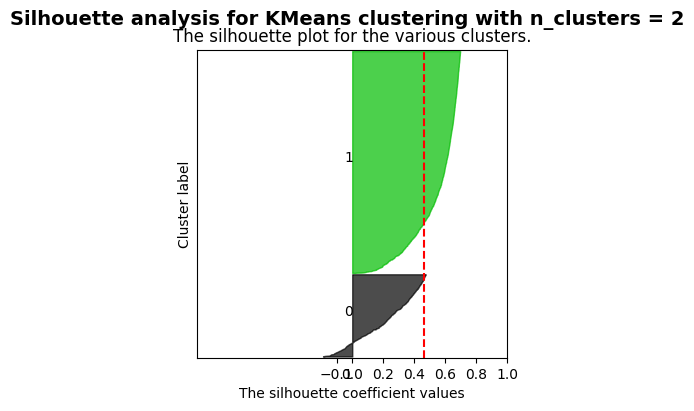

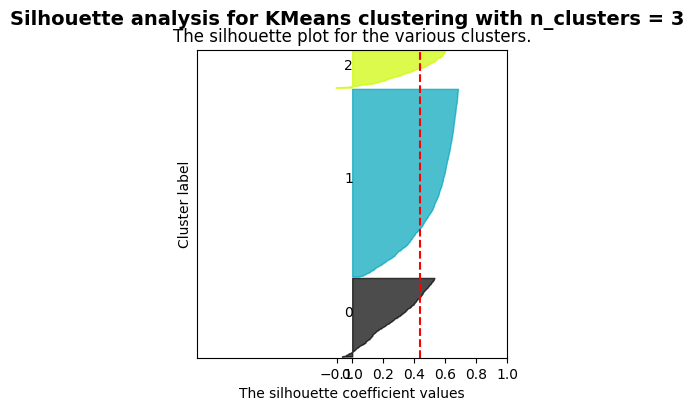

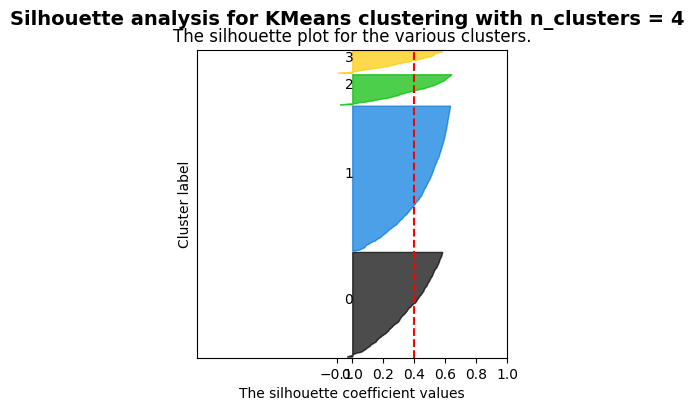

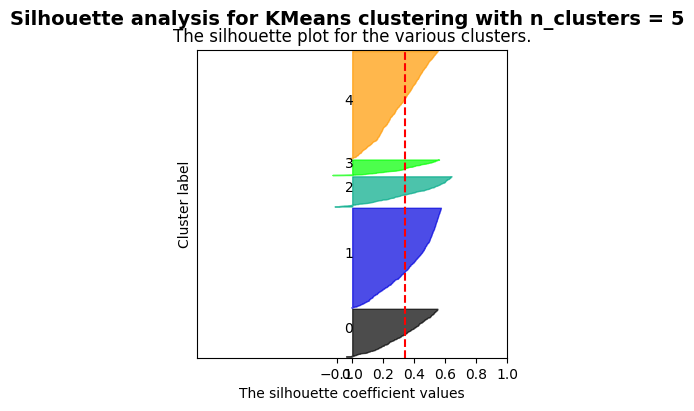

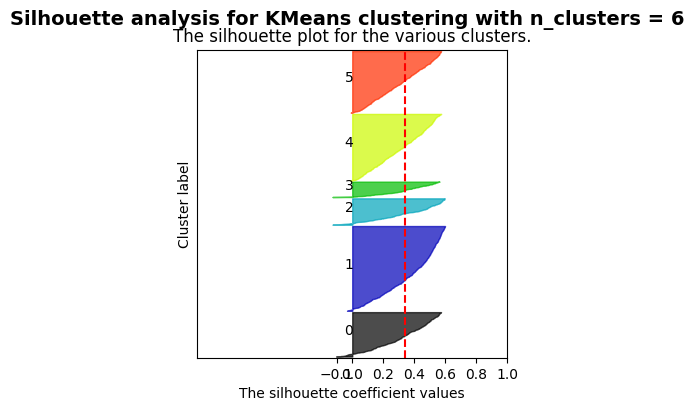

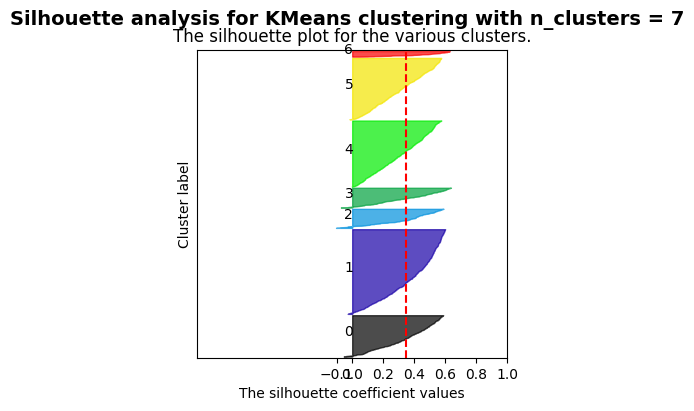

In [ ]:
# Put your code here


**Exercise 1.2** Try to find out the optimal number of clusters [Caliński-Harabasz Index](https://en.wikipedia.org/wiki/Calinski%E2%80%93Harabasz_index). (assuming $k \in [2,7]$). Find more about the sklearn implementation [here](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.calinski_harabasz_score.html).

In [ ]:
# Put your code here


For n_clusters = 2 The Calinski-Harabasz Index is : 1815.7467785566557
For n_clusters = 3 The Calinski-Harabasz Index is : 1697.6921498024146
For n_clusters = 4 The Calinski-Harabasz Index is : 1925.4961331330487
For n_clusters = 5 The Calinski-Harabasz Index is : 1831.9065176921495
For n_clusters = 6 The Calinski-Harabasz Index is : 1796.6630058817855
For n_clusters = 7 The Calinski-Harabasz Index is : 1821.6458810274983


The real power of clustering algorithms lies in the fact that we don't need to limit ourselves to two dimentions (otherwise, we could just cluster the data using a pencil and a sheet of paper).  
This is because they rely on mathematical distances, such as the Euclidean distance, which typically work for any number of dimentions.  
This way, we can use multiple features to cluster our data set.

**Exercise 2.** Perform a k-means clustering on `three_features_log10` with a selected number of clusters and visualize the resuls on an area vs income scatter plot and on a population vs income plot.  
Can you see the differences between this and the previous k-means clustering?

In [ ]:
# Put your code here


**Exercise 2.1** Try to find out the optimal number of clusters using Silhouette measure and Caliński-Harabasz index.

For n_clusters = 2 The average silhouette_score is : 0.4644447593286831
For n_clusters = 3 The average silhouette_score is : 0.37188116278664424
For n_clusters = 4 The average silhouette_score is : 0.3963863151255809
For n_clusters = 5 The average silhouette_score is : 0.3351514663511489
For n_clusters = 6 The average silhouette_score is : 0.3375174850311926
For n_clusters = 7 The average silhouette_score is : 0.32446765875830297


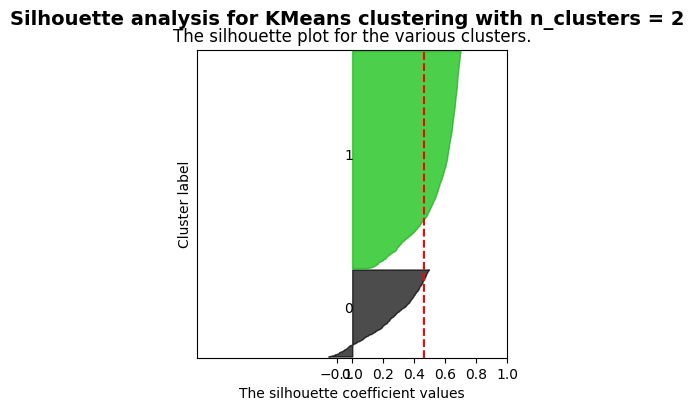

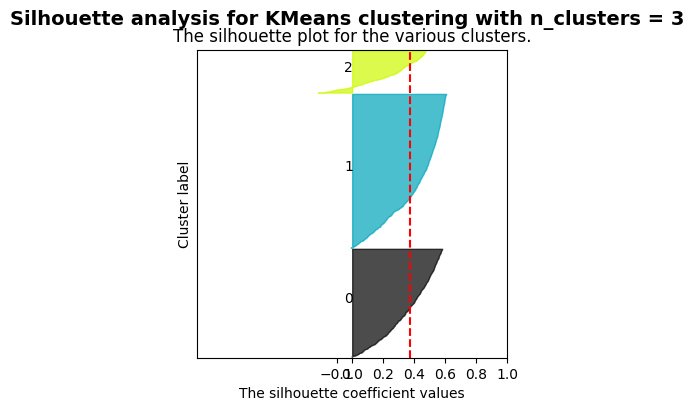

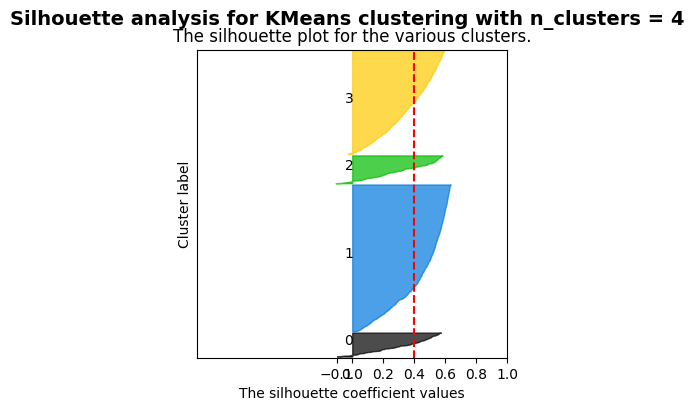

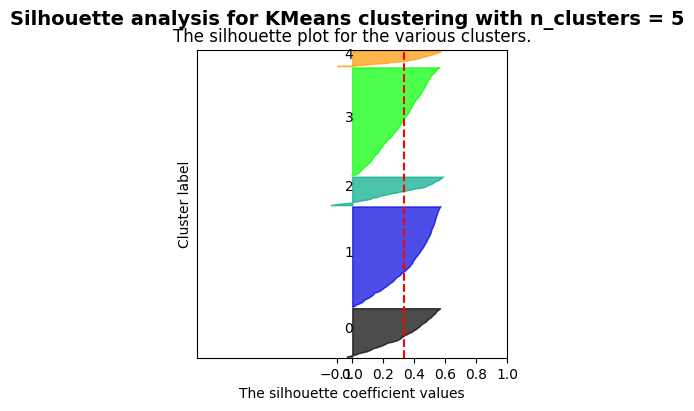

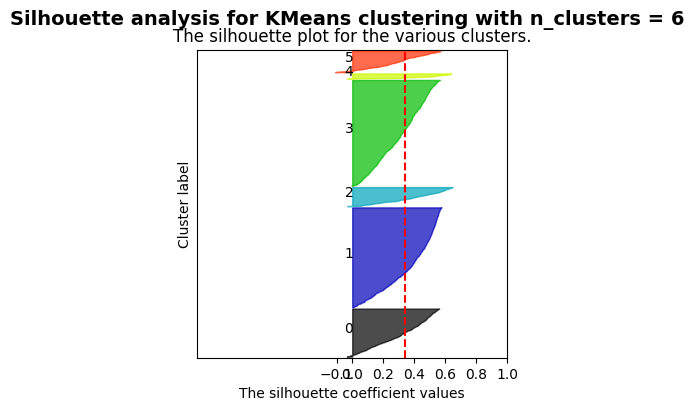

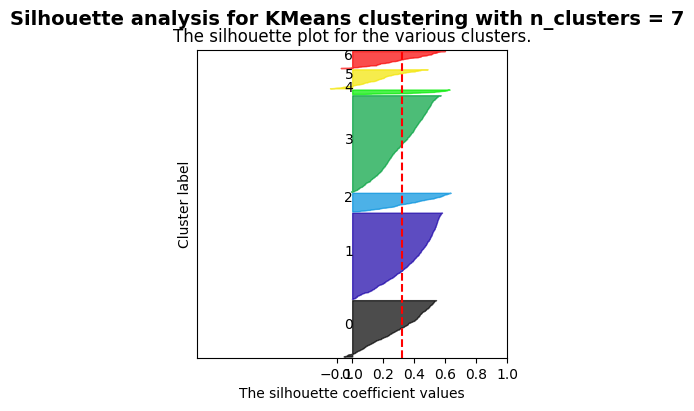

In [ ]:
# Put your code here


In [ ]:
# Put your code here


For n_clusters = 2 The Calinski-Harabasz Index is : 1995.140849134988
For n_clusters = 3 The Calinski-Harabasz Index is : 1517.663160768034
For n_clusters = 4 The Calinski-Harabasz Index is : 1838.266395234507
For n_clusters = 5 The Calinski-Harabasz Index is : 1744.4883759388213
For n_clusters = 6 The Calinski-Harabasz Index is : 1610.527704463252
For n_clusters = 7 The Calinski-Harabasz Index is : 1623.9313440228193


## Hierarchical clustering

A much different approach to clustering is the *hierarchical clustering*, in which we create a tree (called a *dendrogram*) that represents similarity between points and between clusters.  
In the lecture, you will learn more about the single-linkage and the average-linkage algorithms. In this class, we will use another type of linkage, the Ward linkage. The word *linkage* refers to the method of computing distance between clusters.  

The scikit-learn library does not have methods to visualize dendrograms. Therefore, we will use methods from the `scipy` package.  
First, we perform the clustering using the `hierarchy.linkage` method, and then we visualize it using `hierarchy.dendrogram`.  

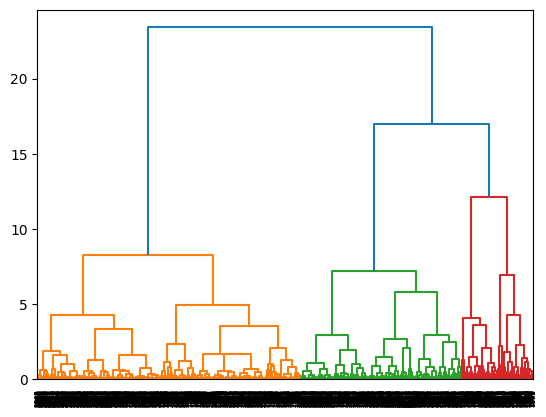

In [ ]:
scipy_clustering = hierarchy.linkage(two_features_log10, method='ward')
dendrogram = hierarchy.dendrogram(scipy_clustering)

The branch lengths above represnt the distances between clusters and allows us to decide on the final number of clusters. For example, if we cut the dendrogram at the height of 15 on the plot above, we get three clusters - represented as the green, red, and cyan subtree.   

**Exercise 3.** Decide on the number of clusters based on the dendrogram. Next, perform hierarchical clustering with the Ward linkage using the `AgglomerativeClustering` function from scikit-learn (imported at the beginning of this notebook).  
You can find documentation and usage examples [here](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html).  
Visualize the results on a scatter plot. How do they compare to the k-means ones? Which do you prefer?  
**Homework:** Check the results for a different affinity (measuring the distance between points) and linkage (measuring the distance between clusters).   

In [ ]:
# Put your code here


**Exercise 4 - homework.** Perform a hierarchical clustering with the selected number of clusters, affinity, and linkage method on the `three_features_log10` data frame.  
Visualize the results on an area vs income scatter plot, and on a population vs income plot.  

In [ ]:
# Put your code here


## Summary

Things to memorize:

- Clustering is a method of grouping points. It can be used to decrease the size of the data set or to detect intresting features without knowing what those features correspond to (*unsupervised learning*).
- Further analyses are needed to understand the real-life meaning of clusters, e.g. what types of municipalities fall into cluster 1 and why.  
- There is no "best" clustering algorithm. Each algorithm performs well for some data sets and poorly for others. It's important to understand how the algorithms work to select the appropriate method for a given data set.  
- There is no "best" clustering for a given data set, but some are obviously bad. You have to choose one that's "good enough".
- The k-means algorithm requires the user to specify the number of clusters before the analysis and produces clusters with similar size and shape.  
- Hierarchical clustering allows to select the number of clusters in a more informed way and can produce clusters of different size and shape, but can be more computationally demanding than k-means. There are many different ways to calculate the similarity between clusters that give different results.

<center><img src='https://drive.google.com/uc?id=1_utx_ZGclmCwNttSe40kYA6VHzNocdET' height="60">

AI TECH - Akademia Innowacyjnych Zastosowań Technologii Cyfrowych. Program Operacyjny Polska Cyfrowa na lata 2014-2020
<hr>

<img src='https://drive.google.com/uc?id=1BXZ0u3562N_MqCLcekI-Ens77Kk4LpPm'>


Projekt współfinansowany ze środków Unii Europejskiej w ramach Europejskiego Funduszu Rozwoju Regionalnego
Program Operacyjny Polska Cyfrowa na lata 2014-2020,
Oś Priorytetowa nr 3 "Cyfrowe kompetencje społeczeństwa" Działanie  nr 3.2 "Innowacyjne rozwiązania na rzecz aktywizacji cyfrowej".   
Tytuł projektu:  „Akademia Innowacyjnych Zastosowań Technologii Cyfrowych (AI Tech)”
    </center>